In [ ]:
from google.colab import files
uploaded = files.upload()


Saving archive.zip to archive.zip


In [ ]:
import zipfile
import os

zip_path = list(uploaded.keys())[0]  # get the uploaded ZIP file name

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("pest_data")

print("Unzipped files into: pest_data")


Unzipped files into: pest_data


In [ ]:
import os

print("", len(os.listdir("pest_data/")))


 12


In [ ]:
!pip install tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 724.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 115.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.1 MB/s eta 0:00:00


In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Data Generator (WITH Augmentation)

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)


Load Training & Validation Data

In [ ]:
train_data = train_gen.flow_from_directory(
    "pest_data",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_data = train_gen.flow_from_directory(
    "pest_data",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)


Found 4399 images belonging to 12 classes.
Found 1095 images belonging to 12 classes.


Load Pretrained Model (MobileNetV2)

In [ ]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # freeze pretrained layers


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Build the Full Model

In [ ]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation="softmax")
])


Compile the Model

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,500 (9.24 MB)

 Trainable params: 165,516 (646.55 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 110s 775ms/step - accuracy: 0.4565 - loss: 1.7526 - val_accuracy: 0.7772 - val_loss: 0.7015
Epoch 2/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 105s 764ms/step - accuracy: 0.7295 - loss: 0.8401 - val_accuracy: 0.7900 - val_loss: 0.6254
Epoch 3/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 104s 755ms/step - accuracy: 0.7580 - loss: 0.7509 - val_accuracy: 0.7954 - val_loss: 0.5977
Epoch 4/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 104s 757ms/step - accuracy: 0.7851 - loss: 0.6894 - val_accuracy: 0.8247 - val_loss: 0.5485
Epoch 5/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 105s 760ms/step - accuracy: 0.7988 - loss: 0.6107 - val_accuracy: 0.8155 - val_loss: 0.5113
Epoch 6/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 104s 753ms/step - accuracy: 0.8126 - loss: 0.5773 - val_accuracy: 0.8311 - val_loss: 0.5133
Epoch 7/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 106s 770ms/step - accuracy: 0.8227 - loss: 0.5481 - val_accuracy: 0.8301 - val_loss: 0.5195
Epoch 8/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 107s 774ms/step - accuracy: 0.8151 -

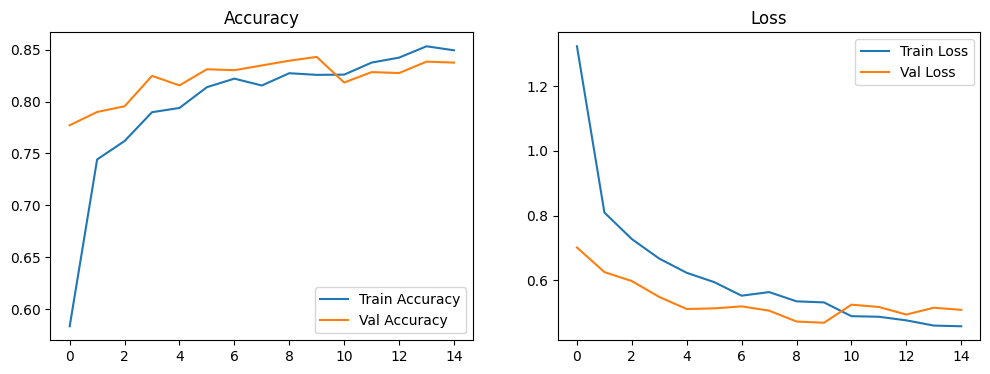

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()


In [ ]:
# Harmfulness labels for each pest class
harmfulness_dict = {
    "ants": ("Harmful", "Protect aphids, damage roots, disturb soil"),
    "beetle": ("Harmful", "Many beetles feed on crops and roots"),
    "catterpillar": ("Harmful", "Eats leaves and destroys crops"),
    "earwig": ("Harmful", "Feeds on fruits, leaves, seedlings"),
    "grasshopper": ("Harmful", "Major crop-eating pest"),
    "moth": ("Harmful", "Larvae damage crops"),
    "slug": ("Harmful", "Eats leaves, vegetables"),
    "snail": ("Harmful", "Damages crops and plants"),
    "weevil": ("Harmful", "Attacks stored grains and crops"),
    "bees": ("Not Harmful", "Pollinators, essential for crops"),
    "earthworms": ("Not Harmful", "Improve soil fertility"),
    "wasp": ("Not Harmful", "Natural pest control (eat other pests)")
}


Saving ants (1).png to ants (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
Predicted Pest: ants
Harm Status: Harmful
Reason: Protect aphids, damage roots, disturb soil


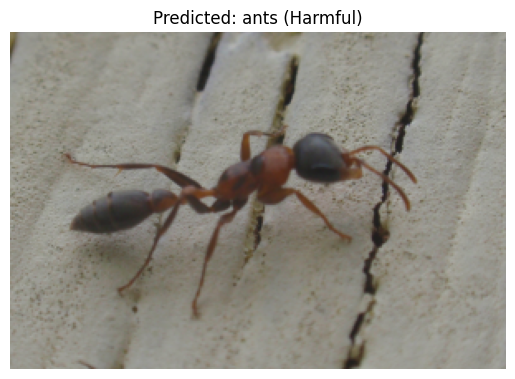

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt

# Upload image
uploaded_img = files.upload()

img_path = list(uploaded_img.keys())[0]
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)
class_index = np.argmax(prediction)
class_name = list(train_data.class_indices.keys())[class_index]

# Look up harmfulness
harm_status, reason = harmfulness_dict.get(class_name, ("Unknown", "No info"))

# Print results
print("Predicted Pest:", class_name)
print("Harm Status:", harm_status)
print("Reason:", reason)

# Display image with prediction
plt.imshow(image.load_img(img_path))
plt.title(f"Predicted: {class_name} ({harm_status})")
plt.axis(False)
plt.show()


In [ ]:
model.save("pest_model.keras")


In [ ]:
import json

class_names = list(train_data.class_indices.keys())

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Saved:", class_names)


Saved: ['ants', 'bees', 'beetle', 'catterpillar', 'earthworms', 'earwig', 'grasshopper', 'moth', 'slug', 'snail', 'wasp', 'weevil']


In [ ]:
from google.colab import files
files.download("class_names.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>